In [ ]:
import h5py
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from h5py import Dataset, File
from jax import vmap

from pathlib import Path

from deepqmc.molecule import Molecule
from deepqmc.hamil import MolecularHamiltonian
from deepqmc.physics import PhysicalConfiguration
from deepqmc.postprocess.workdir import read_workdir

from deepqmc.ecp.gaussian_type_ecp import GaussianTypeECP
from deepqmc.ecp.pseudo_hamiltonian import PseudoHamiltonian

# Employing pseudopotentials and computing Cr ionization energies

In this example, we will employ pseudopotentials to compute accurate ionization energies. Pseudopotentials enable computation of larger systems by replacing the fast-moving core electrons with an additional Hamiltonian term. Using them in DeepQMC is as easy as adding an extra argument `+hamil.ecp_type=ccECP` to your training command.

## 1. Selecting a pseudopotential

DeepQMC implements the following flavours of pseudopotentials:

* **Effective core potentials (ECPs)** — the standard semilocal Gaussian pseudopotentials, evaluated with a nonlocal angular-momentum projector. DeepQMC reads their parameters from [PySCF](https://pyscf.org/) and currently supports the following types:
  * `BFD` from [Burkatzki et al. 2007](https://doi.org/10.1063/1.2741534),
  * `ccECP` from [Bennett et al. 2017](https://doi.org/10.1063/1.4995643).
* **Pseudo-Hamiltonians (PHs)** — a *fully local* alternative that's well suited for QMC calculations, as it folds the core's effect into a modified kinetic operator, entirely avoiding the ECP's costly quadrature computation.
  * `PH` from [Ichibha et al. 2023](https://doi.org/10.1063/5.0175381) and [Fu et al. 2026](https://doi.org/10.1038/s43588-026-01008-7).

While the accuracy of PHs and ECPs is comparable, PHs are much faster. Unfortunately, PHs are only available for a small subset of elements. The following elements support PHs

In [ ]:
from deepqmc.ecp.pseudo_hamiltonian import ELEMENTS_WITH_EXISTING_PH
print([symbol for symbol, _ in ELEMENTS_WITH_EXISTING_PH.values()])

['P', 'S', 'Cl', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn']


We can employ a pseudopotential by setting its `ecp_type` in the command line. The pseudopotential is used for all the atoms except H and He by default. This can be modified by specifying `ecp_mask`, e.g. 
```bash
deepqmc hamil/mol=CH2O +hamil.ecp_type=ccECP +hamil.ecp_mask=[True,False,False,False]
```
would use an ECP for the first atom (oxygen) and all electron treatment of second to fourth atoms (carbon and two hydrogens) in our molecule. The order of atoms is given by the definition of the molecule, in this case the file [CH2O.yaml](https://github.com/deepqmc/deepqmc/blob/master/src/deepqmc/conf/hamil/mol/CH2O.yaml).

### Pretraining

The SCF baseline for supervised pretraining is computed with PySCF. It's recommended to use a Gaussian basis adapted to the specific pseudopotential. We can check the list of available basis sets in the `pyscf.gto.basis.ALIAS` variable. The adapted basis name typically starts with the pseudopotential name, e.g. `BFD_VQZ` or `ccECP_aug-cc-pV5Z`.

```bash
task.pretrain_kwargs.scf_kwargs.basis=ccECP_aug-cc-pV5Z
```

As PySCF doesn't support PH, pretraining is only available for `ccECP`/`BFD` pseudopotentials. When trying to pretrain with `PH` the code defaults to ccECP baseline, a reasonable but not ideal pretraining target.

## 2. Comparison of pseudopotentials to all-electron calculations

We compare the properties on a test system of a single chlorine atom with different pseudopotentials (or no pseudopotential). First, we run the training. If you want fast results to play with, you can decrease the number of training steps (`task.steps`). The output of the runs other than the first were omitted for brevity.

In [ ]:
!deepqmc hamil/mol=Cl task.pretrain_steps=0 task.steps=10000 +task.h5_logger_constructor.keys_whitelist=['local_energy','time'] hydra.run.dir=Cl_timings/all_electron

[2026-07-21 18:30:12.049] INFO:deepqmc.app: Entering application
[2026-07-21 18:30:12.209] INFO:deepqmc.app: Process 0 running on parrot
[2026-07-21 18:30:12.210] INFO:deepqmc.app: Running on 1 NVIDIA GEFORCE RTX 3090 with 1 process
[2026-07-21 18:30:12.210] INFO:deepqmc.app: Will work in Cl_timings/all_electron
[2026-07-21 18:30:12.214] DEBUG:deepqmc.app: Running with code version: a81da0e9
[2026-07-21 18:30:13.264] DEBUG:deepqmc.train: Setting up metric_logger...
[2026-07-21 18:30:13.266] DEBUG:deepqmc.train: Setting up h5_logger...
[2026-07-21 18:30:20.823] INFO:deepqmc.wf.base: Number of model parameters: 1716546
[2026-07-21 18:30:27.181] INFO:deepqmc.train: Equilibrating sampler...
equilibrate sampler:  21%|███    | 213/1000 [01:09<04:15,  3.08it/s, tau=(0.105)]
[2026-07-21 18:31:35.249] INFO:deepqmc.train: Start training
[2026-07-21 18:32:18.584] INFO:deepqmc.train: Progress: 1/10000, energy = (-63(31))
training: 100%|████████████████| 10000/10000 [2:37:52<00:00,  1.06it/s, E=(-1

In [ ]:
!deepqmc hamil/mol=Cl +hamil.ecp_type=ccECP task.pretrain_steps=0 task.steps=10000 +task.h5_logger_constructor.keys_whitelist=['local_energy','time'] hydra.run.dir=Cl_timings/ccECP

In [ ]:
!deepqmc hamil/mol=Cl +hamil.ecp_type=BFD task.pretrain_steps=0 task.steps=10000 +task.h5_logger_constructor.keys_whitelist=['local_energy','time'] hydra.run.dir=Cl_timings/BFD

In [ ]:
!deepqmc hamil/mol=Cl +hamil.ecp_type=PH task.pretrain_steps=0 task.steps=10000 +task.h5_logger_constructor.keys_whitelist=['local_energy','time'] hydra.run.dir=Cl_timings/PH


### Compute time savings

Now, we load the results from the `result.h5` file generated above and print the average step time.

In [ ]:
# workdirs from the four runs above
RUNS = {
    'all-electron': 'Cl_timings/all_electron',
    'BFD':          'Cl_timings/BFD',
    'ccECP':        'Cl_timings/ccECP',
    'PH':           'Cl_timings/PH',
}

def avg_step_time(workdir):
    """Average wall-clock time per step. `time` in result.h5 is cumulative
    seconds since the loop start."""
    times = read_workdir(Path(workdir), ['time'])[0].get('time')
    assert times is not None
    return (times[-1] - times[0]) / (len(times) - 1)


def n_active_electrons(mol_name, ecp_type=None):
    H = MolecularHamiltonian(mol=Molecule.from_name(mol_name), ecp_type=None if ecp_type == 'all-electron' else ecp_type)
    return int(H.n_up + H.n_down)


header = (f"{'method':>12}{'# active el.':>15}{'step time [s]':>17}")
print(header)
print('-' * len(header))
for label, workdir in RUNS.items():
    active_electrons = n_active_electrons('Cl', ecp_type=label)
    t = avg_step_time(workdir)
    print(f"{label:>12}{active_electrons:^15}{t:>17.3f}")

      method   # active el.    step time [s]
--------------------------------------------
all-electron      17                   0.948
         BFD       7                   0.509
       ccECP       7                   0.527
          PH       7                   0.290


All three pseudopotentials cut the step time by removing the Neon core, leaving only 7 valence electrons instead of 17. Both BFD and ccECP pay the same price for evaluating the nonlocal projection operator, while the pseudo-Hamiltonian is the fastest at ~3x over all-electron calculation of Cl atom. Nevertheless, the advantage of pseudopotentials over all-electron treatment grows with system size and with heavier atoms that have larger cores.

### Sampling efficiency and energy variance

Let's evaluate the four trained models from above and inspect the properties of the samples.

In [ ]:
!deepqmc task=evaluate task.steps=1000 task.restdir=Cl_timings/all_electron/training hydra.run.dir=Cl_timings/all_electron_eval +task.observable_monitors=['local_energy','r'] +task.h5_logger_constructor.keys_whitelist=['local_energy','time','tau']

[2026-07-21 11:24:19.627] INFO:deepqmc.app: Entering application
[2026-07-21 11:24:19.779] INFO:deepqmc.app: Process 0 running on parrot
[2026-07-21 11:24:19.779] INFO:deepqmc.app: Running on 1 NVIDIA GEFORCE RTX 3090 with 1 process
[2026-07-21 11:24:19.779] INFO:deepqmc.app: Will work in Cl_timings/all_electron_eval
[2026-07-21 11:24:19.783] DEBUG:deepqmc.app: Running with code version: a81da0e9
[2026-07-21 11:24:20.584] INFO:deepqmc.app: Found original config file in Cl_timings/all_electron/training, from checkpoint LAST
[2026-07-21 11:24:21.181] DEBUG:deepqmc.train: Setting up metric_logger...
[2026-07-21 11:24:21.183] DEBUG:deepqmc.train: Setting up h5_logger...
[2026-07-21 11:24:21.184] INFO:deepqmc.train: Start evaluation
[2026-07-21 11:24:27.633] INFO:deepqmc.train: Equilibrating sampler...
equilibrate sampler:  20%|▉    | 196/1000 [01:06<04:34,  2.93it/s, tau=(0.100)]
[2026-07-21 11:25:34.603] INFO:deepqmc.train: Start evaluation
[2026-07-21 11:26:00.195] INFO:deepqmc.train: Pr

In [ ]:
!deepqmc task=evaluate task.steps=1000 task.restdir=Cl_timings/ccECP/training hydra.run.dir=Cl_timings/ccECP_eval +task.observable_monitors=['local_energy','r'] +task.h5_logger_constructor.keys_whitelist=['local_energy','time','tau']

In [ ]:
!deepqmc task=evaluate task.steps=1000 task.restdir=Cl_timings/BFD/training hydra.run.dir=Cl_timings/BFD_eval +task.observable_monitors=['local_energy','r'] +task.h5_logger_constructor.keys_whitelist=['local_energy','time','tau']

In [ ]:
!deepqmc task=evaluate task.steps=1000 task.restdir=Cl_timings/PH/training hydra.run.dir=Cl_timings/PH_eval +task.observable_monitors=['local_energy','r'] +task.h5_logger_constructor.keys_whitelist=['local_energy','time','tau']

In [ ]:
def tau_and_variance(workdir):
    """Average sampling step size `tau` and local-energy variance over all
    evaluation samples. `sampling/tau` has shape (n_steps, n_mol, n_states);
    `local_energy/samples` has shape (n_steps, n_mol, n_states, 1, n_walkers)."""
    d = read_workdir(Path(workdir), ['sampling/tau', 'local_energy/samples'])[0]
    tau = d.get('sampling/tau')
    samples = d.get('local_energy/samples')
    assert tau is not None and samples is not None
    return float(np.mean(tau)), float(np.var(samples))


header = f"{'method':>12}{'# active el.':>15}{'step time [s]':^17}{'avg tau [a0]':^14}{'energy var [Ha^2]':>18}"
print(header)
print('-' * len(header))
for label, workdir in RUNS.items():
    active_electrons = n_active_electrons('Cl', ecp_type=label)
    step_time = avg_step_time(workdir)                    # training workdir
    tau, var = tau_and_variance(f'{workdir}_eval')        # evaluation workdir
    print(f"{label:>12}{active_electrons:^15}{step_time:^17.3f}{tau:^14.3f}{var:^18.4f}")


      method   # active el.  step time [s]   avg tau [a0]  energy var [Ha^2]
----------------------------------------------------------------------------
all-electron      17             0.948          0.020          90.1364      
         BFD       7             0.509          0.179           0.0116      
       ccECP       7             0.527          0.179           0.0172      
          PH       7             0.290          0.181           0.0089      


Removing some electrons makes the eigenstate problem much simpler. Firstly, the fast-moving core electrons require a small MCMC step size (tau); pseudopotentials enable larger steps, making the sampling of valence electrons much more efficient. Secondly, the energy variance is decreased by about four orders of magnitude which significantly enhances the training efficiency as less noisy samples improve the convergence and training stability.

### What does the pseudopotential look like?

It can be illustrative to look at the shapes of the pseudopotential functions. Here we compare local scalar contribution of different pseudopotentials based on the electron distance from the core. A classical Coulomb potential (dashed line) diverges close to the core whereas all the pseudopotentials avoid this divergence. This generally helps numerical stability.

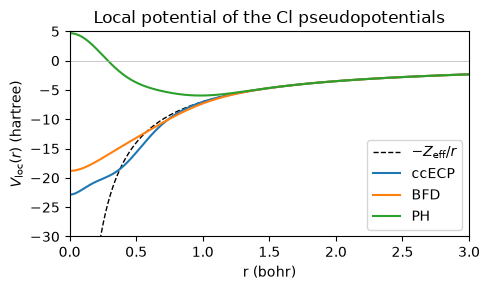

In [ ]:
charges = jnp.array([17.0])
ecp_mask = jnp.array([True])  # pseudize the single Cl nucleus

ecp = GaussianTypeECP(charges, 'ccECP', ecp_mask)
bfd = GaussianTypeECP(charges, 'BFD', ecp_mask)
ph = PseudoHamiltonian(charges, 'PH', ecp_mask)
Z_eff = float(jnp.asarray(ph.ns_valence)[0])  # 7 for Cl
r = jnp.linspace(0.005, 3.0, 400)
rs = r[:, None, None] * jnp.array([1.0, 0.0, 0.0])
phys_conf = PhysicalConfiguration(jnp.zeros((len(r), 1, 3)), rs, mol_idx=jnp.zeros((len(r), 1)))

V_loc_ecp = vmap(ecp.local_potential)(phys_conf)
V_loc_bfd = vmap(bfd.local_potential)(phys_conf)
V_loc_ph = vmap(ph.local_potential)(phys_conf)


plt.figure(figsize=(5, 3))
plt.plot(r, -Z_eff / r, 'k--', lw=1, label=r'$-Z_\mathrm{eff}/r$')
plt.plot(r, V_loc_ecp, label='ccECP')
plt.plot(r, V_loc_bfd, label='BFD')
plt.plot(r, V_loc_ph, label='PH')
plt.axhline(0, color='0.7', lw=0.5)
plt.ylim(-30, 5)
plt.xlabel('r (bohr)')
plt.ylabel(r'$V_\mathrm{loc}(r)$ (hartree)')
plt.title('Local potential of the Cl pseudopotentials')
plt.legend()
plt.xlim(left=0, right=3)
plt.tight_layout()
plt.show()

We can also visualize the one-electron density of the trained wave functions. Having saved all the electron coordinates during evaluation (thanks to `+task.observable_monitors=['local_energy','r']`), we can compute the density using kernel density estimation implemented in `scipy.stats`.

computing density for all-electron ...
computing density for BFD ...
computing density for ccECP ...
computing density for PH ...


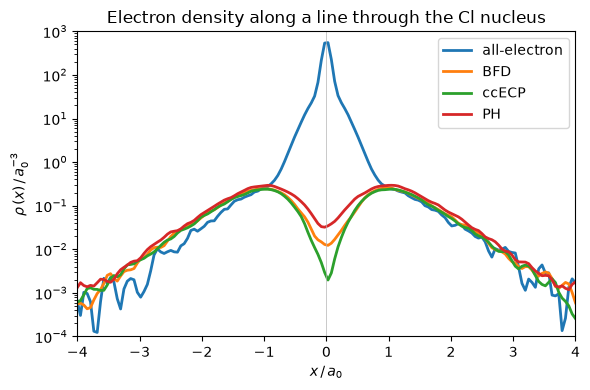

In [ ]:
from scipy.stats import gaussian_kde

x_max = 4.0
max_samples = 4_000_000 # decrease the number of samples if the computation takes too long

# sampling line: the x-axis through the nucleus, i.e. points (x, 0, 0)
x = np.linspace(-x_max-0.0025, x_max, 150)
line_xyz = np.zeros((3, x.size))
line_xyz[0] = x


def get_density_slice(result_path):
    with File(result_path, 'r', swmr=True) as f:
        samples = f['r/samples']
        assert isinstance(samples, Dataset)
        samples = samples[:]        # (..., n_electrons, 3)
    n_electrons = samples.shape[-2]
    positions = samples.reshape(-1, 3)[-max_samples:]
    kde = gaussian_kde(positions.T, bw_method=0.05)
    return kde(line_xyz) * n_electrons


fig, ax = plt.subplots(figsize=(6, 4))
for label, workdir in RUNS.items():
    print(f'computing density for {label} ...')
    density = get_density_slice(f'{workdir}_eval/evaluation/result.h5')
    ax.plot(x, density, label=label, lw=2)

ax.set_yscale('log')
ax.set_xlim(-x_max, x_max)
ax.set_ylim(1e-4, 1e3)
ax.set_xlabel(r'$x\,/\,a_0$')
ax.set_ylabel(r'$\rho\,(x)\,/\,a_0^{-3}$')
ax.axvline(0, color='0.7', lw=0.5)
ax.set_title('Electron density along a line through the Cl nucleus')
ax.legend()
fig.tight_layout()
plt.show()


We can see that pseudopotentials effectively remove the core electrons, avoiding the sharp density peak at the origin while keeping the valence electron density close to the all-electron case.

## 3. Practical example: Ionization energies of Cr atom

Let's walk through a typical application of DeepQMC. Our target is to compute the ionization energies (IEs) of Cr atom using pseudo-Hamiltonians and compare them with the reference CCSD(T) energies from [Ichibha et al. (2023)](https://doi.org/10.1063/5.0175381). 

We start by defining the system of Cr atom
```yaml
# conf/hamil/mol/Cr.yaml
coords: [[0.0, 0.0, 0.0]]
charges: [24]
charge: 0
spin: 6
unit: angstrom
```
where `spin=6` because the ground state ($4s^1 3d^5$) has six unpaired electrons and a total spin of three. The ionized systems can be defined simply by modifying its `charge` and `spin`. Although Ichibha et al. (2023) computed energies for various electronic configurations, we can only compare the ground state energies, because first quantization doesn't allow us to enforce arbitrary orbital occupations (like $4s^2 3d^4$). On the other hand, we can easily target ground and excited states of a specific sector with fixed **charge** and **spin**.

The following calculations require a non-trivial compute time, so it's recommended to run them on a dedicated compute node.

In [ ]:
# neutral ground state 4s1_3d5
!deepqmc hamil/mol=Cr +hamil.ecp_type='PH' task.pretrain_steps=0 task.steps=50000 hydra.run.dir=Cr/state_4s1_3d5
!deepqmc task=evaluate task.steps=2000 task.restdir=Cr/state_4s1_3d5/training hydra.run.dir=Cr/state_4s1_3d5_eval

In [ ]:
# ionized state 4s0_3d5
!deepqmc hamil/mol=Cr hamil.mol.charge=1 hamil.mol.spin=5 +hamil.ecp_type='PH' task.pretrain_steps=0 task.steps=50000 hydra.run.dir=Cr/state_4s0_3d5
!deepqmc task=evaluate task.steps=2000 task.restdir=Cr/state_4s0_3d5/training hydra.run.dir=Cr/state_4s0_3d5_eval

In [ ]:
# 2x ionized state 4s0_3d4
!deepqmc hamil/mol=Cr hamil.mol.charge=2 hamil.mol.spin=4 +hamil.ecp_type='PH' task.pretrain_steps=0 task.steps=50000 hydra.run.dir=Cr/state_4s0_3d4
!deepqmc task=evaluate task.steps=2000 task.restdir=Cr/state_4s0_3d4/training hydra.run.dir=Cr/state_4s0_3d4_eval

In [ ]:
# 3x ionized state 4s0_3d3
!deepqmc hamil/mol=Cr hamil.mol.charge=3 hamil.mol.spin=3 +hamil.ecp_type='PH' task.pretrain_steps=0 task.steps=50000 hydra.run.dir=Cr/state_4s0_3d3
!deepqmc task=evaluate task.steps=2000 task.restdir=Cr/state_4s0_3d3/training hydra.run.dir=Cr/state_4s0_3d3_eval

In [ ]:
# 4x ionized state 4s0_3d2
!deepqmc hamil/mol=Cr hamil.mol.charge=4 hamil.mol.spin=2 +hamil.ecp_type='PH' task.pretrain_steps=0 task.steps=50000 hydra.run.dir=Cr/state_4s0_3d2
!deepqmc task=evaluate task.steps=2000 task.restdir=Cr/state_4s0_3d2/training hydra.run.dir=Cr/state_4s0_3d2_eval

Let's inspect the energies. We also estimate the standard error of the mean energy using nonoverlapping batch means estimator [[Flegal et al.]](https://doi.org/10.1214/08-STS257): assuming the walkers are stationary and independent, each walker trajectory is averaged into one independent energy estimate $\langle E \rangle^i$, and the reported error $\sigma_E$ follows from the spread (stddev of mean) of those estimates


$$
\langle E \rangle^i = \frac{1}{n_\mathrm{s}} \sum_{j=1}^{n_\mathrm{s}} E_\mathrm{loc}[\psi_\theta]\bigl(\{\mathbf{r}\}_{ij}\bigr)\,, \qquad
\langle \sigma_E \rangle = \sqrt{\frac{\sum_{i=1}^{n_\mathrm{b}} \bigl(\langle E \rangle^i - \langle E \rangle\bigr)^2}{n_\mathrm{b}(n_\mathrm{b}-1)}}\,,
$$

where $n_\mathrm{s}$ is the number of steps and $n_\mathrm{b}$ is the batch size (number of walkers).

In [ ]:
CR    = Path('Cr')
STATES = [
    ("ground", "state_4s1_3d5_eval", "4s1_3d5"),
    ("ion +1", "state_4s0_3d5_eval", "4s0_3d5"),
    ("ion +2", "state_4s0_3d4_eval", "4s0_3d4"),
    ("ion +3", "state_4s0_3d3_eval", "4s0_3d3"),
    ("ion +4", "state_4s0_3d2_eval", "4s0_3d2"),
]

def nolbm_sem(x):
    """Non-overlapping batch means standard error of the mean."""
    x = np.squeeze(x)
    x_walker_means = x.mean(axis=0)
    n = len(x_walker_means)
    return np.sqrt(np.sum((x_walker_means - x_walker_means.mean())**2) / (n * (n - 1)))


def load_dqmc(eval_dir):
    with h5py.File(CR / eval_dir / "evaluation" / "result.h5", "r", swmr=True) as f:
        energy_samples = f["local_energy/samples"][:]
        step_mean = f["local_energy/mean"][:].ravel()
    return step_mean.mean(), nolbm_sem(energy_samples)

for label, eval_dir, elec_config in STATES:
    e, sem = load_dqmc(eval_dir)
    print(f"{label}: E={e:.4f}({sem*1e4:.0f}) Ha")

ground: E=-86.9325(3) Ha
ion +1: E=-86.6867(3) Ha
ion +2: E=-86.0800(4) Ha
ion +3: E=-84.9362(4) Ha
ion +4: E=-83.1166(57) Ha


We immediately notice that the standard deviation of the last energy is significantly higher than the rest. This could indicate either poorly converged wave function or some issue with the sampling. It's best to check the statistics of the evaluation run using tensorboard.
```bash
tensorboard --logdir Cr/state_4s0_3d2_eval
```
From the tensorboard dashboard we'd easily see that the energies are not stationary, see the plot below.

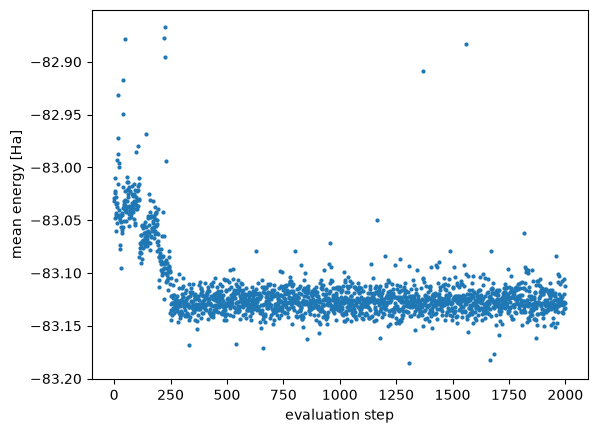

In [ ]:
with h5py.File(CR / "state_4s0_3d2_eval" / "evaluation" / "result.h5", "r", swmr=True) as f:
    E_samples = np.squeeze(f["local_energy/samples"][:])
    E_mean_per_step = E_samples.mean(axis=1)
plt.scatter(np.arange(len(E_mean_per_step)), E_mean_per_step, s=4)
plt.xlabel('evaluation step')
plt.ylabel('mean energy [Ha]')
plt.show()

Apparently, the walkers were not well equilibrated when the evaluation started and only become stationary after the first ~250 steps. A simple solution would be to trim the first 250 not-well-equilibrated steps. Alternatively, we could rerun the evaluation with increased equilibration steps by adding the following arguments
```bash
deepqmc task=evaluate task.steps=2000 task.restdir=Cr/state_4s0_3d2/training hydra.run.dir=Cr/state_4s0_3d2_eval_rerun +task.max_eq_steps=1000 +task.eq_allow_early_stopping=false
```
This particular issue was caused by a single walker (out of 1000) that was unluckily initialized, so this result may not be exactly reproducible on different hardware or package versions. If we would consider removing the problematic walker(s), we'd have to be very careful not to introduce a bias this way.

state              |      E_qmc          E_cc     E_qmc-E_cc |    IE_qmc     IE_cc     IE_ae   qmc err
                   |      [Ha]           [Ha]          [mHa] |      [Ha]      [Ha]      [Ha]     [mHa]
------------------------------------------------------------------------------------------------------
ground  4s1_3d5    |   -86.9325 (3)    -86.9306       -1.88  |    0.0000    0.0000    0.0000      0.00
ion +1  4s0_3d5    |   -86.6867 (3)    -86.6844       -2.39  |    0.2457    0.2462    0.2486     -2.85
ion +2  4s0_3d4    |   -86.0800 (4)    -86.0778       -2.20  |    0.8525    0.8528    0.8560     -3.49
ion +3  4s0_3d3    |   -84.9362 (4)    -84.9237      -12.50  |    1.9962    2.0069    2.0064    -10.17
ion +4  4s0_3d2    |   -83.1264 (3)    -83.1224       -4.01  |    3.8061    3.8082    3.8030      3.08


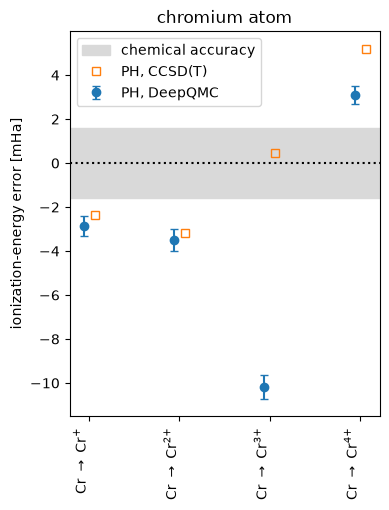

In [ ]:
STATES[4] = ("ion +4", "state_4s0_3d2_eval_rerun", "4s0_3d2")
chem_acc_mHa = 1.5936            # 1 kcal/mol
ref_energies = { # CCSD(T) energies in Hartree from [Ichibha et al.]
 '4s1_3d5': {'e_ae': -1050.6679553745112, 'e_ph': -86.93058217817133}, # ground state       spin=6 charge=0
 '4s0_3d5': {'e_ae': -1050.4193822459104, 'e_ph': -86.68436007609742}, # ionized state      spin=5 charge=1
 '4s0_3d4': {'e_ae': -1049.8119994200401, 'e_ph': -86.07779727684246}, # 2x ionized state   spin=4 charge=2
 '4s0_3d3': {'e_ae': -1048.6615402992910, 'e_ph': -84.92371408706438}, # 3x ionized state   spin=3 charge=3
 '4s0_3d2': {'e_ae': -1046.8649420667916, 'e_ph': -83.12237117478182}, # 4x ionized state   spin=2 charge=4
}


# --- generate table of energies ---
rows = []
for label, eval_dir, elec_config in STATES:
    e, sem = load_dqmc(eval_dir)
    ref = ref_energies[elec_config]
    rows.append(dict(label=label+'  '+elec_config, e_dqmc=e, sem=sem, e_ae=ref["e_ae"], e_ph=ref["e_ph"]))
ground = rows[0]
ions = rows[1:] 

for r in rows:
    r["dev_ph"]   = r["e_dqmc"] - r["e_ph"]                # ABSOLUTE: DeepQMC - PH-CCSD(T)
    r["rel_dqmc"] = r["e_dqmc"] - ground["e_dqmc"]         # ionization energy (DeepQMC)
    r["rel_ph"]   = r["e_ph"]   - ground["e_ph"]           # ionization energy (PH ref.)
    r["rel_ae"]   = r["e_ae"]   - ground["e_ae"]           # ionization energy (all-electron ref.)
    r["rel_sem"]  = np.sqrt(r["sem"]**2 + ground["sem"]**2)
    r["err"]      = r["rel_dqmc"] - r["rel_ae"]            # DeepQMC ion-energy error vs ae
    r["err_ph"]   = r["rel_ph"]  - r["rel_ae"]             # PH ion-energy error vs ae

# --- table ---
header = (f"{'state':18s} | {'E_qmc':^15s} {'E_cc':^12s} {'E_qmc-E_cc':>10s} "
       f"| {'IE_qmc':>9s} {'IE_cc':>9s} {'IE_ae':>9s} {'qmc err':>9s}")
subheader = (f"{'':18s} | {'[Ha]':^15s} {'[Ha]':^12s} {'[mHa]':>10s} "
       f"| {'[Ha]':>9s} {'[Ha]':>9s} {'[Ha]':>9s} {'[mHa]':>9s}")
print(header)
print(subheader)
print("-" * len(header))
for r in rows:
    print(f"{r['label']:18s} | {r['e_dqmc']:10.4f} ({r['sem']*1e4:.0f}) {r['e_ph']:11.4f}  "
          f"{r['dev_ph']*1e3:10.2f}  | {r['rel_dqmc']:9.4f} {r['rel_ph']:9.4f} "
          f"{r['rel_ae']:9.4f} {r['err']*1e3:9.2f}")


# --- plot ---
x    = np.arange(len(ions))
lab = [rf"Cr $\rightarrow$ Cr$^{{{'' if i == 1 else i}\!+}}$" for i in range(1, 5)]
err_dqmc = np.array([r["err"]*1e3 for r in ions])
err_ph   = np.array([r["err_ph"]*1e3 for r in ions])
sem_ev   = np.array([r["rel_sem"]*1e3 for r in ions])

fig, ax = plt.subplots(figsize=(4, 5))
ax.axhspan(-chem_acc_mHa, chem_acc_mHa, color="0.85", label="chemical accuracy")
ax.axhline(0, color="k", linestyle=":")
ax.errorbar(x - 0.06, err_dqmc, yerr=sem_ev, fmt="o", capsize=3, label="PH, DeepQMC")
ax.plot(x + 0.06, err_ph, "s", mfc="none", label="PH, CCSD(T)")
ax.set_ylabel("ionization-energy error [mHa]")
ax.set_title("chromium atom")
ax.set_xticks(x)
ax.set_xticklabels(lab, rotation=90, ha="right")
ax.legend()
plt.show()

The first two ionization energies agree with Ichibha's pseudo-Hamiltonian calculations (squares). The third IE is underestimated by about 10 mHa. The fact that DeepQMC yielded lower energy compared to CC for $\mathrm{Cr}^{3+}$ suggests that this state might have not been perfectly captured by the reference CCSD(T) method. The pseudo-Hamiltonian was fitted to produce correct IE of Cr using the CCSD(T) method, which explains why these values agree with the all-electron reference while DeepQMC + PH energy is slightly off despite being more accurate for the given Hamiltonian. Note that the relative IE error is still small, about 0.5 %. And it is just 0.08 % for the fourth IE.

## 4. [Advanced] User-defined pseudopotentials

Although not directly supported, advanced users can experiment with custom pseudopotentials. The implementation differs between ECP and PH, so we'll show both types separately.

### Custom ECP

DeepQMC loads effective core potentials via PySCF, which supports custom ECPs. To use them conveniently, you can create a new folder `deepqmc/src/deepqmc/conf/hamil/ecp` and save new ECPs in NWChem format there in a `.yaml` that hydra picks up, e.g.

```yaml
# deepqmc/src/deepqmc/conf/hamil/ecp/custom_ecp.yaml
# @package hamil
# Example custom ECP for chlorine in NWChem format.
ecp_type: |
  ECP
  Cl nelec 10
  Cl ul
  1        7.944352000      7.000000000
  2        6.296744000    -22.860784000
  3       12.801261000     55.610463000
  Cl s
  2       17.908432000     15.839234000
  2        4.159880000     44.469504000
  Cl p
  2        7.931763000      8.321946000
  2        3.610412000     24.044745000
```

After that, you can simply run
```bash
deepqmc hamil/mol=Cl +hamil/ecp=custom_ecp
```

### Custom PH

Pseudo-Hamiltonians, on the other hand, are loaded directly from `.xml` files from internal folder at `deepqmc/src/deepqmc/ecp/ph_data`. The XML format follows the QMCPACK-style convention storing a tabulated grid of `r*V` values. We can add a new file `Cl.custom.xml` there and reference it from the command line as
```bash
deepqmc hamil/mol=Cl +hamil.ecp_type=PHcustom
```